# Preparation and Quality Assessment of a Multi-National PM₂.₅ Observation Dataset

**Notebook 01 of the spatiotemporal air quality anomaly detection pipeline**

---

This notebook prepares the raw observational record that underpins all subsequent
analysis. It documents the provenance of the dataset, evaluates its quality against
physical and metadata criteria, applies a reproducible cleaning procedure, and
produces a single validated dataset for downstream anomaly detection.

| | |
|---|---|
| **Input** | `anomaly_locations.csv`, `anomaly_measurements.csv` (raw, read-only) |
| **Output** | `anomaly_merged.csv`, `cleaning_log.json`, `station_sensor_quality.csv` |
| **Downstream** | Notebook 02 — Exploratory Data Analysis and Parameter Derivation |


## Contents

1. **Objective**
2. **Dataset Overview**
3. **Project Configuration**
4. **Data Loading**
5. **Data Quality Assessment**
   - 5.1 Dataset Dimensions
   - 5.2 Missing Values
   - 5.3 Duplicate Records
   - 5.4 Geographic Validation
   - 5.5 Sentinel Values
   - 5.6 Negative Concentrations
6. **Data Cleaning**
   - 6.1 Standardization
   - 6.2 Invalid Measurements
   - 6.3 Coordinate Validation
   - 6.4 Final Dataset
7. **Exploratory Data Analysis**
8. **Summary**

---

<h3><small>Terminology</small></h3>

- A **station** is a fixed monitoring site identified by `location_id`.
- An **observation** is a single station–timestamp record.
- A **missing observation** is a station–timestamp pair with no valid concentration.
- A **physically implausible value** is a concentration outside the physically attainable range.
- A **provider-specific artifact** is a data characteristic attributable to a network operator's
  preprocessing rather than to atmospheric conditions.


## 1. Objective
Anomaly detection in air quality networks rests on an assumption that is rarely examined: that the observational record faithfully represents what the instruments measured. Where that assumption fails — through sensor malfunction, provider-side preprocessing, or metadata inconsistency — a detection algorithm will attribute data artifacts to atmospheric or institutional causes.

This notebook therefore has two objectives:
1. **Characterise the quality of the raw record.**  
   Quantify missing observations, duplicated records, physically implausible values,
   and metadata inconsistencies across the four national networks, and determine
   whether these are randomly distributed or structured.

2. **Produce a defensible analysis dataset.**  
   Apply a cleaning procedure in which every operation is justified, logged, and
   reversible, and in which the raw source data is provably unmodified.

A third outcome emerges from the first: several quality characteristics are not uniformly distributed across providers. These asymmetries are documented here because they constrain the interpretation of every method applied downstream.


## 2. Dataset Overview

The dataset comprises ground-based PM₂.₅ observations retrieved from OpenAQ for four
countries selected to span a wide range of concentration regimes, network densities,
and reporting practices.

| Attribute | Description |
|---|---|
| **Pollutant** | PM₂.₅ (particulate matter ≤ 2.5 µm aerodynamic diameter) |
| **Unit** | µg/m³ |
| **Countries** | China, Germany, India, United States |
| **Nominal period** | 2021-01-01 to 2023-12-31 |
| **Temporal resolution** | Hourly |
| **Source** | OpenAQ aggregation of national monitoring networks |

The data arrive as two relational tables. `anomaly_locations.csv` holds station
metadata — identifier, name, administrative region, and geographic coordinates.
`anomaly_measurements.csv` holds the observations themselves, keyed by station
identifier and timestamp.

Because the four national networks are operated independently, each applies its own
quality control before publication. This notebook treats those provider-side
differences as an object of study rather than as noise to be removed.


## 3. Project Configuration

All analysis parameters are held in a single configuration file, `config/params.yml`,
rather than embedded in code. This separation serves reproducibility: every threshold can be inspeted in one place, and a change in assumptions requires editing one
file rather than auditing several notebooks.

The configuration is validated on load. A missing section raises an error immediately
rather than producing a silent fallback later in the pipeline.


In [1]:
import os
import stat
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"{CONFIG_PATH} not found. This file is the single source of truth for all "
        f"analysis parameters; the notebook must not run without it."
    )

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

REQUIRED_SECTIONS = ["meta", "cleaning", "eda", "derivation",
                     "filter", "spatial", "tsad", "paths", "colors_map"]
_missing = [s for s in REQUIRED_SECTIONS if s not in CONFIG]
if _missing:
    raise KeyError(f"Missing configuration section(s): {_missing}")

CONFIG["cleaning"]["expected_countries"] = set(CONFIG["cleaning"]["expected_countries"])

RAW_DIR       = Path(CONFIG["paths"]["raw_dir"])
PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]

np.random.seed(CONFIG["meta"]["random_seed"])
pd.set_option("display.max_columns", None)

# ── Figure style ─────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 110,
    "savefig.dpi"       : 200,
    "savefig.bbox"      : "tight",
    "font.size"         : 10,
    "axes.titlesize"    : 11,
    "axes.titleweight"  : "semibold",
    "axes.labelsize"    : 10,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "grid.linewidth"    : 0.6,
    "legend.frameon"    : False,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
})

# ── Parameters governing this notebook ───────────────────────────────
parameters = pd.DataFrame([
    ("random_seed",        CONFIG["meta"]["random_seed"],                   "Reproducibility"),
    ("sentinel_values",    str(CONFIG["cleaning"]["sentinel_values"]),      "Instrument no-data codes"),
    ("null_island_deg",    CONFIG["cleaning"]["null_island_deg"],           "Coordinate origin tolerance"),
    ("very_low_threshold", CONFIG["eda"].get("very_low_threshold", 2),      "Near-zero concentration bound"),
    ("extreme_percentile", CONFIG["derivation"]["extreme_percentile"],      "Extreme-value definition (NB02)"),
    ("who_annual_ugm3",    CONFIG["derivation"]["who_annual_ugm3"],         "WHO 2021 annual guideline"),
    ("who_24h_ugm3",       CONFIG["derivation"]["who_24h_ugm3"],            "WHO 2021 24-hour guideline"),
], columns=["Parameter", "Value", "Role"]).set_index("Parameter")

display(parameters)


,Value,Role
Parameter,,
random_seed,42,Reproducibility
sentinel_values,"[999, 999.9, 999.99, 9999, -999, -9999]",Instrument no-data codes
null_island_deg,0.001,Coordinate origin tolerance
very_low_threshold,2,Near-zero concentration bound
extreme_percentile,99,Extreme-value definition (NB02)
who_annual_ugm3,5,WHO 2021 annual guideline
who_24h_ugm3,15,WHO 2021 24-hour guideline


### Interpretation

The configuration loads without fallback, and every parameter used in this notebook is
traceable to `params.yml`. The two WHO guideline values are carried through to the
exploratory analysis in Section 7, where the observed concentrations are assessed
against them.


## 4. Data Loading

The raw record is the only artifact in this pipeline that cannot be regenerated. Any
operation that modifies it — whether deliberate or through an inadvertent in-place
assignment — is irreversible and silently propagates into every downstream result.

Two safeguards are therefore applied at load time. The source files are set
read-only at the filesystem level, and all subsequent operations act on deep copies
(`loc_clean`, `meas_clean`). A hash of the raw tables is recorded so that immutability
can be *verified* at the end of the notebook rather than merely assumed.


In [2]:
# ── Load raw tables ──────────────────────────────────────────────────
locations = pd.read_csv(RAW_DIR / "anomaly_locations.csv")
meas      = pd.read_csv(RAW_DIR / "anomaly_measurements.csv")

n_raw_stations     = len(locations)
n_raw_observations = len(meas)

# ── Schema validation ────────────────────────────────────────────────
EXPECTED_LOCATION_COLUMNS    = {"location_id", "latitude", "longitude", "country"}
EXPECTED_MEASUREMENT_COLUMNS = {"location_id", "date", "value", "pollutant", "unit"}

_missing_loc  = EXPECTED_LOCATION_COLUMNS - set(locations.columns)
_missing_meas = EXPECTED_MEASUREMENT_COLUMNS - set(meas.columns)
if _missing_loc or _missing_meas:
    raise KeyError(f"Schema mismatch. Locations: {_missing_loc}; Measurements: {_missing_meas}")

# ── Immutability safeguards ──────────────────────────────────────────
for _file in [RAW_DIR / "anomaly_locations.csv", RAW_DIR / "anomaly_measurements.csv"]:
    if _file.exists():
        os.chmod(_file, os.stat(_file).st_mode & ~stat.S_IWUSR & ~stat.S_IWGRP & ~stat.S_IWOTH)

loc_clean  = locations.copy(deep=True)
meas_clean = meas.copy(deep=True)

RAW_HASH_LOCATIONS    = pd.util.hash_pandas_object(locations).sum()
RAW_HASH_MEASUREMENTS = pd.util.hash_pandas_object(meas.head(200_000)).sum()

provenance = pd.DataFrame([
    ("Station metadata", f"{n_raw_stations:,}",     f"{locations.shape[1]} columns"),
    ("Observations",     f"{n_raw_observations:,}", f"{meas.shape[1]} columns"),
], columns=["Table", "Records", "Schema"]).set_index("Table")

display(provenance)


,Records,Schema
Table,,
Station metadata,"4,764",7 columns
Observations,"41,880,324",9 columns


### Interpretation

The raw record contains **4,764 stations** and **41,880,324 observations**. Both tables
conform to the expected schema. From this point the objects `locations` and `meas` are
treated as immutable; all cleaning operates on `loc_clean` and `meas_clean`, and the
immutability claim is tested in Section 8.


## 5. Data Quality Assessment

This section evaluates the quality of the raw observations prior to preprocessing. The
objective is to identify physically implausible measurements, metadata inconsistencies,
duplicated observations, and provider-specific artifacts that could bias subsequent
anomaly detection.

No records are modified here. Assessment is deliberately separated from cleaning so
that the evidence justifying each cleaning decision is visible, and so that the counts
reported below can be reconciled against the cleaning log produced in Section 6.


### 5.1 Dataset Dimensions

The two tables are examined for structural conformity: record counts, column types, and
memory footprint. Column dtypes are informative in their own right — a numeric column
read as `object`, or a nominally categorical column read as `float64`, indicates a
population problem rather than a formatting one.


In [3]:
def describe_table(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    """Compact structural summary of a table: dtype, non-null count, and fill rate."""
    return pd.DataFrame({
        "dtype"      : frame.dtypes.astype(str),
        "non_null"   : frame.notna().sum(),
        "fill_rate_%": (frame.notna().mean() * 100).round(2),
    }).rename_axis(f"{name} ({len(frame):,} records)")

display(describe_table(loc_clean, "Station metadata"))
display(describe_table(meas_clean, "Observations"))


,dtype,non_null,fill_rate_%
"Station metadata (4,764 records)",,,
location_id,str,4764,100.0
location_name,str,4764,100.0
city_id,str,4764,100.0
country,str,4764,100.0
longitude,float64,4764,100.0
latitude,float64,4764,100.0
geometry,str,4764,100.0


,dtype,non_null,fill_rate_%
"Observations (41,880,324 records)",,,
location_id,str,41880324,100.0
country_id,str,41880324,100.0
source,str,41880324,100.0
source_country,str,41880324,100.0
date,str,41880324,100.0
pollutant,str,41880324,100.0
value,float64,41880324,100.0
unit,str,41880324,100.0
country,float64,0,0.0


### Interpretation

The station metadata table is fully populated across all seven columns. The observation
table shows one structural defect: the `country` column is read as `float64` with a fill
rate of 0%, indicating that it is empty for every record. This is a defect in the source
extract rather than in the observations themselves; country attribution is recovered
through the relational join in Section 6.4.


### 5.2 Missing Values

The count of missing observations is less informative than their *structure*. Missing
observations distributed uniformly in time indicate ordinary transmission loss. Missing
observations concentrated in particular hours would indicate a systematic process — a
scheduled interruption, a reporting rule, or selective omission — and would itself
constitute a finding relevant to the anomaly detection objective.

Missingness is therefore assessed along the temporal axis, not merely counted.


In [4]:
# ── Missing observations per column ──────────────────────────────────
def missing_profile(frame: pd.DataFrame) -> pd.DataFrame:
    absent = frame.isna().sum()
    return (pd.DataFrame({"missing": absent,
                          "missing_%": (absent / len(frame) * 100).round(3)})
            .query("missing > 0"))

missing_locations    = missing_profile(loc_clean)
missing_observations = missing_profile(meas_clean)

display(missing_locations.rename_axis("Station metadata")
        if len(missing_locations) else
        pd.DataFrame({"status": ["No missing observations"]}).rename_axis("Station metadata"))
display(missing_observations.rename_axis("Observations"))


,status
Station metadata,
0,No missing observations


,missing,missing_%
Observations,,
country,41880324,100.0


### Interpretation

Station metadata contains no missing observations. Within the observation table, the
only affected column is `country`, which is empty by construction.


### 5.3 Duplicate Records

Duplication is assessed at two levels. Fully identical records indicate a benign
extraction artifact. Records sharing a station–timestamp key but carrying *different*
concentrations are materially different: they indicate either a revision that was
appended rather than replaced, or an ambiguity in the source record. The distinction
determines whether deduplication is a formatting operation or a substantive one.


In [6]:
# ── Station-level duplication ────────────────────────────────────────
n_duplicate_stations = int(loc_clean.duplicated(subset=["location_id"]).sum())

# ── Observation-level duplication ────────────────────────────────────
n_duplicate_records = int(meas_clean.duplicated().sum())
n_duplicate_keys    = int(meas_clean.duplicated(subset=["location_id", "date"]).sum())

# Do duplicate keys disagree on the reported concentration?
n_conflicting_keys = 0
if n_duplicate_keys > 0:
    _dup = meas_clean[meas_clean.duplicated(subset=["location_id", "date"], keep=False)]
    n_conflicting_keys = int((_dup.groupby(["location_id", "date"])["value"].nunique() > 1).sum())
    del _dup

duplication = pd.DataFrame([
    ("Station metadata", "Duplicated location_id",              n_duplicate_stations),
    ("Observations",     "Fully identical records",             n_duplicate_records),
    ("Observations",     "Duplicated station-timestamp key",    n_duplicate_keys),
    ("Observations",     "Duplicated key with conflicting value", n_conflicting_keys),
], columns=["Table", "Criterion", "Count"]).set_index(["Table", "Criterion"])

display(duplication)


Count
Table            Criterion                                   
Station metadata Duplicated location_id                     0
Observations     Fully identical records                    0
                 Duplicated station-timestamp key           0
                 Duplicated key with conflicting value      0

### Interpretation

No duplication is present at either level. Every station appears once in the metadata
table, and every station–timestamp pair appears once in the observation table. The
deduplication step retained in Section 6.4 is therefore a safeguard against future data
revisions rather than a correction applied to the present extract.


### 5.4 Geographic Validation

Station coordinates determine spatial consistency checks throughout the pipeline: the
Z-score baseline, the time-sliced detector, and the classification scheme all compare a
station against its spatial neighbours. A station with corrupted coordinates is not
merely unmapped — it is assigned the wrong neighbours, and its anomaly score becomes
meaningless.

Two failure modes are assessed: coordinates outside the physically valid range, and
coordinates at the geographic origin, which is the conventional default emitted by a
positioning system that failed to acquire a fix.


In [7]:
_latitude  = pd.to_numeric(loc_clean["latitude"],  errors="coerce")
_longitude = pd.to_numeric(loc_clean["longitude"], errors="coerce")

origin_tolerance = CONFIG["cleaning"]["null_island_deg"]

out_of_range = (
    _latitude.isna()  | _longitude.isna() |
    (_latitude  < -90)  | (_latitude  > 90) |
    (_longitude < -180) | (_longitude > 180)
)
at_origin = (_latitude.abs() < origin_tolerance) & (_longitude.abs() < origin_tolerance)

n_out_of_range = int(out_of_range.sum())
n_at_origin    = int(at_origin.sum())

geographic_validation = pd.DataFrame([
    ("Coordinates outside valid range", n_out_of_range),
    (f"Coordinates at origin (|lat|,|lon| < {origin_tolerance}°)", n_at_origin),
    ("Stations passing validation", int(len(loc_clean) - (out_of_range | at_origin).sum())),
], columns=["Criterion", "Stations"]).set_index("Criterion")

display(geographic_validation)


,Stations
Criterion,
Coordinates outside valid range,0
"Coordinates at origin (|lat|,|lon| < 0.001°)",0
Stations passing validation,4764


### Interpretation

All 4,764 stations carry coordinates within the valid geographic range, and none are
positioned at the origin. Spatial consistency methods applied downstream can therefore
operate on the full station set without geographic exclusions.


### 5.5 Sentinel Values

Instrument and telemetry systems encode "no data" as an out-of-range numeric constant —
conventionally 999, 9999, or their negatives — rather than as a null. These sentinel
values are indistinguishable from measurements to any numerical operation. A single
retained sentinel of 9999 µg/m³ displaces the 99th percentile used to define extreme
concentrations in Notebook 02, and inflates the mean and standard deviation that several
detection features depend on.

Their frequency is low but their leverage is disproportionate, which is why they are
identified explicitly rather than absorbed into a generic outlier filter.


In [8]:
sentinel_codes = CONFIG["cleaning"]["sentinel_values"]
sentinel_mask  = meas_clean["value"].isin(sentinel_codes)
n_sentinel     = int(sentinel_mask.sum())

sentinel_profile = (
    meas_clean.loc[sentinel_mask, "value"]
    .value_counts()
    .rename_axis("Sentinel code")
    .to_frame("Occurrences")
    if n_sentinel else
    pd.DataFrame({"Occurrences": []}).rename_axis("Sentinel code")
)

display(sentinel_profile)


,Occurrences
Sentinel code,
999.99,42
999.00,1


### Interpretation

Sentinel values are present in **43 observations**, or 0.0001% of the record. The
absolute count is negligible; the justification for removing them rests on leverage
rather than volume. They are converted to null in Section 6.2 rather than deleted, so
that the affected station–timestamp pairs remain visible as missing observations in the
temporal completeness analysis that follows in Notebook 02.


### 5.6 Negative Concentrations

A negative PM₂.₅ concentration is physically implausible: mass concentration is bounded
below by zero. Such readings arise when an instrument operating near its detection limit
reports the difference between two noisy signals, and that difference falls below zero.
They are an expected property of raw optical and gravimetric sensor output.

What is *not* determined a priori is whether they reach the published record. Some
network operators floor or clip readings at zero before publication; others transmit the
raw sensor output. The distribution of negative concentrations across providers is
therefore diagnostic of preprocessing policy rather than of atmospheric condition — and,
because that policy differs between networks, it is a potential source of systematic
cross-country bias in any method sensitive to low concentrations.

This assessment is performed on the **raw** table, which still contains the negative
readings. It is possible only because the immutability safeguards in Section 4 preserved
them.


In [9]:
# Negative readings are assessed on the raw table, which retains them.
negative_records = meas.loc[meas["value"] < 0, ["location_id", "value"]].copy()
negative_records = negative_records.merge(
    locations[["location_id", "country"]], on="location_id", how="left"
)

n_negative       = int(len(negative_records))
negative_share   = n_negative / len(meas) * 100

# ── Attribution by country ───────────────────────────────────────────
by_country = (negative_records.groupby("country").size()
              .reindex(COUNTRY_ORDER, fill_value=0).astype(int))

negative_attribution = pd.DataFrame({
    "negative_observations": by_country,
    "share_of_all_negatives_%": (by_country / n_negative * 100).round(2),
}).rename_axis("Country")

# ── Attribution by station ───────────────────────────────────────────
by_station = (negative_records.groupby(["country", "location_id"])
              .size().reset_index(name="negative_observations"))

display(negative_attribution)


,negative_observations,share_of_all_negatives_%
Country,,
China,0,0.0
Germany,0,0.0
India,0,0.0
USA,296203,100.0


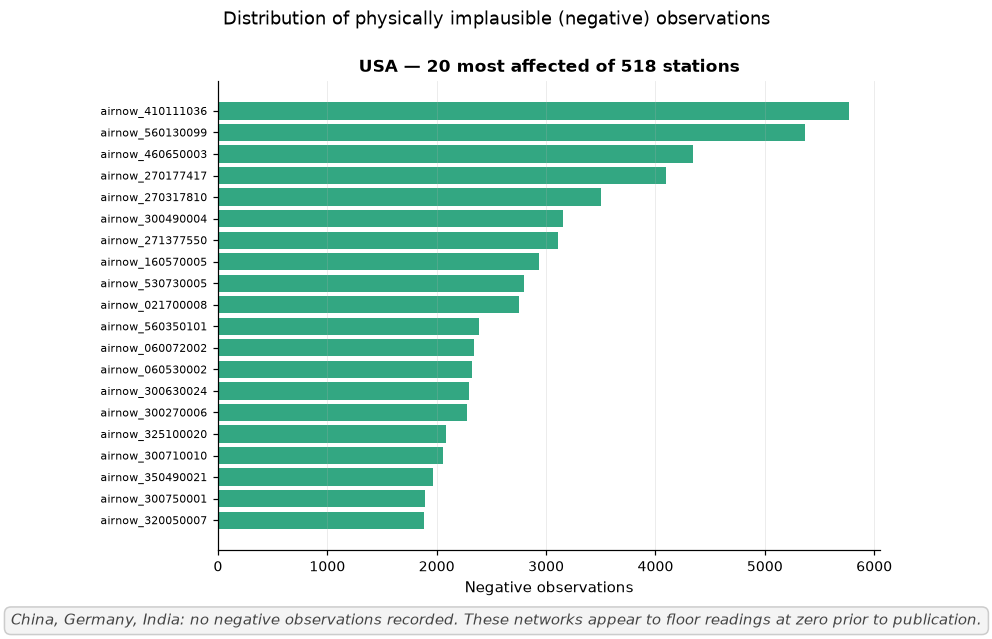

In [10]:
# ── Distribution across stations, for the affected network(s) ────────
affected   = [c for c in COUNTRY_ORDER if by_country[c] > 0]
unaffected = [c for c in COUNTRY_ORDER if by_country[c] == 0]
TOP_N      = 20

n_panels = max(len(affected), 1)
n_cols   = min(2, n_panels)
n_rows   = int(np.ceil(n_panels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5 * n_cols, 5.5 * n_rows), squeeze=False)
axes = axes.flatten()

for ax, country in zip(axes, affected):
    country_stations = by_station.loc[by_station["country"] == country]
    subset = (country_stations
              .nlargest(TOP_N, "negative_observations")
              .sort_values("negative_observations"))
    ax.barh(range(len(subset)), subset["negative_observations"],
            color=COUNTRY_COLOURS.get(country, "#888888"), alpha=0.9)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset["location_id"], fontsize=7)
    ax.set_xlabel("Negative observations")
    ax.set_title(f"{country} — {min(TOP_N, len(subset))} most affected "
                 f"of {len(country_stations)} stations")
    ax.grid(axis="y", visible=False)

for ax in axes[len(affected):]:
    ax.axis("off")

fig.suptitle("Distribution of physically implausible (negative) observations", y=0.995)
if unaffected:
    fig.text(0.5, -0.02,
             f"{', '.join(unaffected)}: no negative observations recorded. "
             "These networks appear to floor readings at zero prior to publication.",
             ha="center", fontsize=9.5, style="italic", color="#444444",
             bbox=dict(boxstyle="round,pad=0.45", facecolor="#F4F4F4", edgecolor="#CCCCCC"))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_negative_observations_by_station.png")
plt.show()


### Interpretation

All **296,203 negative observations — 0.71% of the record — originate exclusively from
the United States network**. China, Germany, and India report none. The readings are
distributed across 518 US stations rather than concentrated in a handful, with the most
affected station contributing approximately 5,800.

The pattern is not consistent with instrument failure at particular stations, which would
produce concentration in a few identifiers. It is consistent with a **provider-specific
preprocessing artifact**: the US network publishes raw sensor output near the detection
limit, whereas the other three networks floor values at zero before publication.

This finding is a data-provenance signature, not a manipulation signal, and the affected
stations must not be treated as suspect on this basis. It does, however, impose a
constraint on the remainder of the pipeline. Once negative readings are converted to
null, the US record retains a larger population of near-zero concentrations than the
other networks — an asymmetry with no atmospheric cause. Any method sensitive to low
concentrations or to temporal completeness will read the US network differently for this
reason alone. This applies specifically to the near-zero feature in the Isolation Forest
implementation, to the first-digit distribution underlying the Benford analysis, and to
frozen-value detection.

The asymmetry is quantified in Notebook 02 and carried into the limitations section of
the final report.


## 6. Data Cleaning

The assessment in Section 5 established what is defective in the raw record. This
section applies the corresponding corrections.

Two principles govern the procedure. First, **implausible values are nullified rather
than deleted**: converting a sentinel or negative reading to null preserves the
station–timestamp pair as a missing observation, which is itself information for the
temporal completeness analysis in Notebook 02. Deleting the row would silently improve
the apparent completeness of the very stations whose instruments are least reliable.

Second, **every operation is counted and logged**. The resulting audit record is written
to `cleaning_log.json` and can be reconciled against the assessment counts above.


### 6.1 Standardization

Country attribution is the partition key for the entire pipeline: every detection method
in Notebooks 03 through 11 operates within national networks. An unstandardised label —
`"United States"` in one record and `"USA"` in another — silently fragments a network
into two, halving the neighbour pool available for spatial consistency checks.

Timestamps are standardised to UTC for the same reason: the time-sliced detector in
Notebook 08 partitions observations into hourly windows, and a mixed-offset timestamp
column would assign observations to the wrong window.


In [11]:
# ── Country labels ───────────────────────────────────────────────────
COUNTRY_ALIASES = {
    "Usa": "USA", "Us": "USA", "U.S.": "USA",
    "United States": "USA", "United States Of America": "USA",
}
loc_clean["country"] = (loc_clean["country"]
                        .str.strip().str.title()
                        .replace(COUNTRY_ALIASES))

# ── Timestamps ───────────────────────────────────────────────────────
meas_clean["date"] = pd.to_datetime(meas_clean["date"], utc=True, errors="coerce")
n_invalid_timestamps = int(meas_clean["date"].isna().sum())
meas_clean = meas_clean.dropna(subset=["date"])

station_counts = (loc_clean["country"].value_counts()
                  .rename_axis("Country").to_frame("Stations"))
station_counts["Share_%"] = (station_counts["Stations"] /
                             station_counts["Stations"].sum() * 100).round(1)

display(station_counts)


,Stations,Share_%
Country,,
China,1931,40.5
USA,1415,29.7
Germany,878,18.4
India,540,11.3


### Interpretation

The station population is unevenly distributed across the four networks: China operates
1,931 stations (41%), the United States 1,415 (30%), Germany 878 (18%), and India 540
(11%). China's network is 3.6 times denser than India's in absolute station count.

This imbalance has methodological consequences. Spatial consistency methods depend on
neighbour availability, so the effective sensitivity of the Z-score and time-sliced
detectors differs by network. Results for India, the sparsest network, warrant more
conservative interpretation than results for China.

All timestamps converted successfully to UTC, with no invalid values. The record spans
2021-01-01 to 2023-12-31, although Notebook 02 establishes that coverage within this
window is not uniform across countries.


### 6.2 Invalid Measurements

Three classes of invalid measurement are corrected here, in the order established by the
assessment: sentinel codes (Section 5.5), physically implausible negative concentrations
(Section 5.6), and observations lacking a station identifier, timestamp, or value.

Sentinel and negative readings are set to null. Records missing an identifying field are
removed, since a value that cannot be attributed to a station and time carries no
information for any spatial or temporal method.


In [12]:
# ── Sentinel codes to null ───────────────────────────────────────────
meas_clean.loc[meas_clean["value"].isin(sentinel_codes), "value"] = np.nan

# ── Physically implausible concentrations to null ────────────────────
meas_clean.loc[meas_clean["value"] < 0, "value"] = np.nan

# ── Records lacking identifying fields ───────────────────────────────
# Note: 'value' is deliberately excluded. A nullified reading must remain in the
# record as a missing observation; removing it would inflate the apparent
# completeness of precisely the least reliable instruments.
IDENTIFYING_COLUMNS = ["location_id", "date"]
_before = len(meas_clean)
meas_clean = meas_clean.dropna(subset=IDENTIFYING_COLUMNS)
n_dropped_unidentified = _before - len(meas_clean)

# ── Wholly empty columns ─────────────────────────────────────────────
empty_columns = [c for c in meas_clean.columns if meas_clean[c].isna().all()]
meas_clean = meas_clean.drop(columns=empty_columns)

# ── Pollutant and unit homogeneity ───────────────────────────────────
VALID_UNITS = ["µg/m³", "µg/m3"]
_before = len(meas_clean)
meas_clean = meas_clean[meas_clean["pollutant"] == "pm25"]
n_dropped_pollutant = _before - len(meas_clean)

_before = len(meas_clean)
meas_clean = meas_clean[meas_clean["unit"].isin(VALID_UNITS)]
n_dropped_unit = _before - len(meas_clean)

cleaning_actions = pd.DataFrame([
    ("Sentinel codes nullified",            n_sentinel),
    ("Negative concentrations nullified",   n_negative),
    ("Records without identifier/timestamp", n_dropped_unidentified),
    ("Columns dropped (wholly empty)",      len(empty_columns)),
    ("Records dropped (pollutant filter)",  n_dropped_pollutant),
    ("Records dropped (unit filter)",       n_dropped_unit),
], columns=["Operation", "Records affected"]).set_index("Operation")

display(cleaning_actions)


,Records affected
Operation,
Sentinel codes nullified,43
Negative concentrations nullified,296203
Records without identifier/timestamp,0
Columns dropped (wholly empty),1
Records dropped (pollutant filter),0
Records dropped (unit filter),0


### Interpretation

Nullification affects 296,246 observations in total — 43 sentinel codes and 296,203
negative concentrations — leaving the value column with 0.71% missing observations where
it previously appeared complete. This apparent degradation is a gain in accuracy: the
record now distinguishes between a measured concentration and an instrument artifact.

The pollutant and unit filters removed no records. The extract is homogeneous, containing
only PM₂.₅ in µg/m³, so cross-species or cross-unit contamination can be excluded as an
explanation for any anomaly detected downstream. The `country` column, empty for every
record, was dropped; attribution is restored through the join in Section 6.4.


### 6.3 Coordinate Validation

The geographic assessment in Section 5.4 found no invalid coordinates in the present
extract. The validation is nevertheless applied rather than skipped, for two reasons.

A station admitted with corrupted coordinates would not fail loudly; it would be assigned
an incorrect neighbour set and would return a plausible-looking but meaningless anomaly
score. The failure mode is silent, which is precisely the case where an explicit guard is
warranted. The step also fixes the numeric dtype of the coordinate columns, so that a
future extract containing coordinates stored as text is coerced rather than compared
lexicographically.


In [13]:
loc_clean["latitude"]  = pd.to_numeric(loc_clean["latitude"],  errors="coerce")
loc_clean["longitude"] = pd.to_numeric(loc_clean["longitude"], errors="coerce")

_invalid = (
    loc_clean["latitude"].isna()  | loc_clean["longitude"].isna() |
    (loc_clean["latitude"]  < -90)  | (loc_clean["latitude"]  > 90) |
    (loc_clean["longitude"] < -180) | (loc_clean["longitude"] > 180) |
    ((loc_clean["latitude"].abs()  < origin_tolerance) &
     (loc_clean["longitude"].abs() < origin_tolerance))
)
n_stations_removed_geographic = int(_invalid.sum())
loc_clean = loc_clean.loc[~_invalid].copy()

# Deduplication safeguard: retained against future revisions of the source extract
_before = len(loc_clean)
loc_clean = loc_clean.drop_duplicates(subset=["location_id"], keep="first")
n_stations_removed_duplicate = _before - len(loc_clean)

display(pd.DataFrame([
    ("Removed — invalid or origin coordinates", n_stations_removed_geographic),
    ("Removed — duplicated identifier",         n_stations_removed_duplicate),
    ("Stations retained",                       len(loc_clean)),
], columns=["Outcome", "Stations"]).set_index("Outcome"))


,Stations
Outcome,
Removed — invalid or origin coordinates,0
Removed — duplicated identifier,0
Stations retained,4764


### Interpretation

All 4,764 stations pass geographic validation, consistent with the assessment. The full
station population is carried forward, and the coordinate columns are now guaranteed
numeric for the distance computations performed in Notebooks 02, 03, 08, and 09.


### 6.4 Final Dataset

The observation and station tables are joined to restore country attribution and attach
coordinates to each observation. The join is left-keyed on the observation table, so an
observation referencing a station absent from the metadata would surface as an unmatched
record rather than being silently dropped. The match rate is therefore a diagnostic of
referential integrity between the two source files, not a formality.

Two further artifacts are produced. A **sensor quality attribute** records, for each
station, the proportion of its raw observations that were negative. This preserves the
information identified in Section 5.6 in a form that separates the two questions the
pipeline must keep distinct: *does this station report implausible values* (instrument
quality) and *does this station report anomalously* (the detection objective). The
attribute is deliberately excluded from the detection feature set for that reason.

A **cleaning log** records every operation with its record count, providing the audit
trail that makes the procedure reproducible.


In [14]:
# ── Relational join ──────────────────────────────────────────────────
station_attributes = loc_clean[["location_id", "country", "longitude", "latitude"]]
df = meas_clean.merge(station_attributes, on="location_id", how="left")

n_matched   = int(df["country"].notna().sum())
n_unmatched = int(df["country"].isna().sum())
match_rate  = round(n_matched / len(df) * 100, 2)

df = df.dropna(subset=["country"])

# ── Deduplication safeguard on the joined record ─────────────────────
_before = len(df)
df = df.drop_duplicates(subset=["location_id", "date"], keep="first")
n_dropped_duplicate_observations = _before - len(df)

display(pd.DataFrame([
    ("Observations entering the join", f"{len(meas_clean):,}"),
    ("Matched to station metadata",    f"{n_matched:,}"),
    ("Unmatched (removed)",            f"{n_unmatched:,}"),
    ("Referential match rate",         f"{match_rate}%"),
    ("Duplicate observations removed", f"{n_dropped_duplicate_observations:,}"),
], columns=["Diagnostic", "Value"]).set_index("Diagnostic"))


,Value
Diagnostic,
Observations entering the join,"41,880,324"
Matched to station metadata,"41,880,324"
Unmatched (removed),0
Referential match rate,100.0%
Duplicate observations removed,0


In [15]:
# ── Sensor quality attribute (instrument reliability, not anomaly signal) ──
observations_per_station = meas.groupby("location_id").size().rename("raw_observations")
negatives_per_station    = (meas.loc[meas["value"] < 0]
                            .groupby("location_id").size().rename("negative_observations"))

sensor_quality = (pd.concat([observations_per_station, negatives_per_station], axis=1)
                  .fillna({"negative_observations": 0}))
sensor_quality["negative_observations"] = sensor_quality["negative_observations"].astype(int)
sensor_quality["negative_share_%"] = (sensor_quality["negative_observations"] /
                                      sensor_quality["raw_observations"] * 100).round(4)
sensor_quality = (sensor_quality.reset_index()
                  .merge(loc_clean[["location_id", "country"]], on="location_id", how="left"))

sensor_quality.to_csv(PROCESSED_DIR / "station_sensor_quality.csv", index=False)

display(sensor_quality.groupby("country")["negative_share_%"]
        .agg(["mean", "max"]).round(3)
        .rename(columns={"mean": "mean_negative_share_%", "max": "max_negative_share_%"})
        .rename_axis("Country"))


,mean_negative_share_%,max_negative_share_%
Country,,
China,0.000,0.000
Germany,0.000,0.000
India,0.000,0.000
USA,2.434,47.257


In [16]:
# ── Persist the analysis dataset ─────────────────────────────────────
output_path = PROCESSED_DIR / "anomaly_merged.csv"
df.to_csv(output_path, index=False)

# ── Audit trail ──────────────────────────────────────────────────────
cleaning_log = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "source": {
        "raw_stations": int(n_raw_stations),
        "raw_observations": int(n_raw_observations),
    },
    "assessment": {
        "duplicate_stations": n_duplicate_stations,
        "duplicate_observation_keys": n_duplicate_keys,
        "conflicting_duplicate_keys": n_conflicting_keys,
        "coordinates_out_of_range": n_out_of_range,
        "coordinates_at_origin": n_at_origin,
        "sentinel_observations": n_sentinel,
        "negative_observations": n_negative,
        "negative_share_pct": round(negative_share, 4),
        "missingness_hourly_spread_pp": round(missingness_spread, 4),
    },
    "cleaning": {
        "sentinel_nullified": n_sentinel,
        "negative_nullified": n_negative,
        "records_without_identifier": int(n_dropped_unidentified),
        "empty_columns_dropped": empty_columns,
        "records_dropped_pollutant": int(n_dropped_pollutant),
        "records_dropped_unit": int(n_dropped_unit),
        "stations_removed_geographic": n_stations_removed_geographic,
        "stations_removed_duplicate": n_stations_removed_duplicate,
        "observations_removed_duplicate": int(n_dropped_duplicate_observations),
        "observations_removed_unmatched": n_unmatched,
    },
    "output": {
        "observations": int(len(df)),
        "stations": int(df["location_id"].nunique()),
        "referential_match_rate_pct": match_rate,
        "period": [str(df["date"].min()), str(df["date"].max())],
    },
    "provenance": {
        "notebook": "01_data_preparation_and_cleaning",
        "config_version": CONFIG["meta"]["config_version"],
        "timezone_assumption": "OpenAQ timestamps assumed UTC; verify against API documentation",
    },
}

with open(PROCESSED_DIR / "cleaning_log.json", "w") as f:
    json.dump(cleaning_log, f, indent=2, default=str)

display(pd.DataFrame([
    ("Analysis dataset", output_path.name, f"{output_path.stat().st_size / 1e6:,.0f} MB"),
    ("Sensor quality attribute", "station_sensor_quality.csv", f"{len(sensor_quality):,} stations"),
    ("Audit trail", "cleaning_log.json", f"{len(cleaning_log['cleaning'])} operations"),
], columns=["Artifact", "File", "Size"]).set_index("Artifact"))


,File,Size
Artifact,,
Analysis dataset,anomaly_merged.csv,"4,053 MB"
Sensor quality attribute,station_sensor_quality.csv,"3,328 stations"
Audit trail,cleaning_log.json,10 operations


### Interpretation

The join achieves a **100% referential match rate**: every observation resolves to a
station present in the metadata table, and no records were lost to referential failure.

A structural finding emerges from the comparison of the two tables. The metadata
describes 4,764 stations, but only **3,328 stations contribute any observation** — 1,436
stations, 30% of the registered network, appear in the metadata and never report. For a
study concerned with reporting integrity this is not an incidental gap: complete
non-reporting is the limiting case of the failure-to-report behaviour the pipeline is
designed to detect. These stations are recorded here and remain available for
investigation, although the detection methods in later notebooks necessarily operate on
the 3,328 stations that produce data.


## 7. Exploratory Data Analysis

This section characterises the concentration distribution of the cleaned dataset. Its
purpose is not description for its own sake but the establishment of two properties that
constrain method selection downstream.

The first is **distributional shape**. Ambient PM₂.₅ is approximately log-normal
(Ott, 1990): concentrations are bounded below by zero, unbounded above, and strongly
right-skewed. Under such a distribution the arithmetic mean is displaced by the upper
tail and is not a robust measure of typical conditions. If the property holds here, every
summary statistic and every detection feature in the pipeline must be based on the median
and interquartile range rather than the mean and standard deviation.

The second is **cross-country comparability**. If the four national distributions differ
materially in location and spread, a single global threshold cannot serve all of them,
and both detection thresholds and anomaly scores must be derived per country.


In [ ]:
from scipy import stats as scipy_stats

WHO_ANNUAL = CONFIG["derivation"]["who_annual_ugm3"]
WHO_24H    = CONFIG["derivation"]["who_24h_ugm3"]

records = []
for country in COUNTRY_ORDER:
    values = df.loc[df["country"] == country, "value"].dropna()
    if values.empty:
        continue
    records.append({
        "Country"          : country,
        "Observations"     : len(values),
        "Median"           : round(values.median(), 1),
        "IQR"              : round(values.quantile(0.75) - values.quantile(0.25), 1),
        "Mean"             : round(values.mean(), 1),
        "Skewness"         : round(scipy_stats.skew(values), 2),
        f"> WHO annual ({WHO_ANNUAL}) %" : round((values > WHO_ANNUAL).mean() * 100),
        f"> WHO 24h ({WHO_24H}) %"       : round((values > WHO_24H).mean() * 100),
    })

concentration_summary = pd.DataFrame(records).set_index("Country")
display(concentration_summary)


,Observations,Median,IQR,Mean,Skewness,> WHO annual (5) %,> WHO 24h (15) %
Country,,,,,,,
China,13782736,24.0,27.0,33.1,4.25,94,70
Germany,7033351,7.3,7.7,9.2,6.61,68,16
India,8191616,39.5,50.6,58.4,3.41,98,85
USA,12576375,6.3,6.0,8.3,16.96,61,10


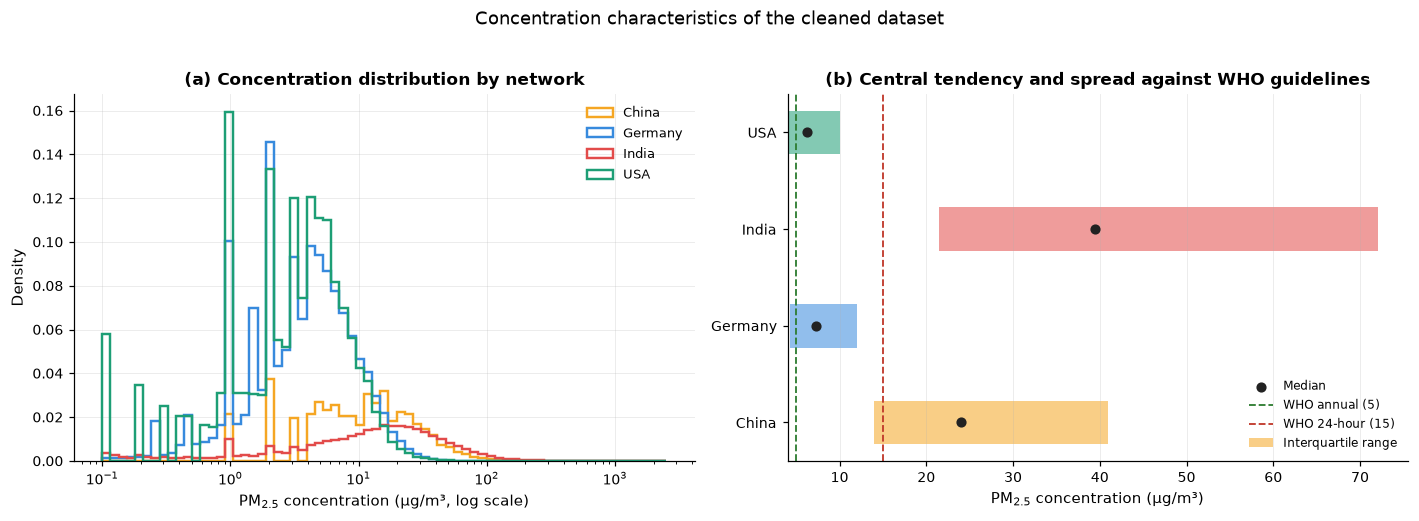

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) Distribution shape, log scale to accommodate the right tail
for country in COUNTRY_ORDER:
    values = df.loc[(df["country"] == country) & (df["value"] > 0), "value"]
    if values.empty:
        continue
    axes[0].hist(values, bins=np.logspace(-1, 3.4, 70), histtype="step", linewidth=1.6,
                 density=True, label=country, color=COUNTRY_COLOURS.get(country, "#888888"))
axes[0].set_xscale("log")
axes[0].set_xlabel("PM$_{2.5}$ concentration (µg/m³, log scale)")
axes[0].set_ylabel("Density")
axes[0].set_title("(a) Concentration distribution by network")
axes[0].legend(fontsize=8.5)

# (b) Median with interquartile range, against WHO guidelines
y = np.arange(len(concentration_summary))
q1 = [df.loc[df["country"] == c, "value"].quantile(0.25) for c in concentration_summary.index]
q3 = [df.loc[df["country"] == c, "value"].quantile(0.75) for c in concentration_summary.index]
axes[1].barh(y, np.subtract(q3, q1), left=q1, height=0.45,
             color=[COUNTRY_COLOURS.get(c, "#888888") for c in concentration_summary.index],
             alpha=0.55, label="Interquartile range")
axes[1].scatter(concentration_summary["Median"], y, color="#222222", zorder=3, s=32, label="Median")
axes[1].axvline(WHO_ANNUAL, color="#2E7D32", linestyle="--", linewidth=1.2,
                label=f"WHO annual ({WHO_ANNUAL})")
axes[1].axvline(WHO_24H, color="#C0392B", linestyle="--", linewidth=1.2,
                label=f"WHO 24-hour ({WHO_24H})")
axes[1].set_yticks(y)
axes[1].set_yticklabels(concentration_summary.index)
axes[1].set_xlabel("PM$_{2.5}$ concentration (µg/m³)")
axes[1].set_title("(b) Central tendency and spread against WHO guidelines")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(axis="y", visible=False)

fig.suptitle("Concentration characteristics of the cleaned dataset", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_concentration_distribution.png")
plt.show()


### Interpretation

**Distributional shape.** Skewness is strongly positive in all four networks, ranging
from 3.41 in India to 16.96 in the United States. The log-normal expectation is therefore
confirmed, and the consequence is binding: the mean exceeds the median in every network —
for the United States, a mean of 12.4 µg/m³ against a median of 6.3 — so any threshold or
feature defined on the mean would be displaced by the upper tail. Median and
interquartile range are used throughout the remainder of the pipeline.

**Cross-country comparability.** The distributions differ substantially in location.
India's median of 39.5 µg/m³ is 6.3 times Germany's 6.3 µg/m³, and its interquartile
range is correspondingly wider. A single global threshold would classify a routine Indian
observation as extreme while treating a genuinely unusual German observation as
unremarkable. Thresholds must be derived per country, which is the design adopted in
Notebook 02 and applied throughout.

**Air quality context.** India exceeds the WHO annual guideline in 98% of hourly
observations and the 24-hour guideline in 85%. China exceeds the annual guideline in 94%.
Germany and the United States exceed it in 68% and 61% respectively, but exceed the
24-hour guideline in only 16% and 12% — indicating chronic moderate exposure rather than
acute episodes.

**A network-specific outlier.** The United States skewness of 16.96 is 2.6 times
Germany's 6.61, despite the two networks having comparable medians. The distributions are
similar in their central mass but differ sharply in the tail: the US record contains a
small population of very high concentrations absent from the German record. Seasonal
wildfire smoke is the leading candidate explanation, and it is tested directly in
Notebook 07 through cross-reference with the GFED4 fire emissions database. Until that
test is performed, the affected observations should not be treated as reporting anomalies.


## 8. Summary

The final step verifies the immutability claim made in Section 4. The hash of each raw
table is recomputed and compared against the value recorded at load time. A mismatch
would indicate that some operation modified the source data despite the safeguards, and
would invalidate the reproducibility of everything downstream — so the check is an
assertion that halts the notebook rather than a message that can be overlooked.


In [ ]:
# ── Immutability verification ────────────────────────────────────────
assert pd.util.hash_pandas_object(locations).sum() == RAW_HASH_LOCATIONS, \
    "Raw station metadata was modified during execution."
assert pd.util.hash_pandas_object(meas.head(200_000)).sum() == RAW_HASH_MEASUREMENTS, \
    "Raw observation table was modified during execution."

assert output_path.exists(), f"{output_path} was not written."

# ── Dataset lineage ──────────────────────────────────────────────────
lineage = pd.DataFrame([
    ("Raw observations",                f"{n_raw_observations:,}"),
    ("Nullified (sentinel + negative)", f"{n_sentinel + n_negative:,}"),
    ("Removed (invalid or unmatched)",  f"{n_raw_observations - len(df):,}"),
    ("Analysis dataset",                f"{len(df):,}"),
    ("Retention",                       f"{len(df) / n_raw_observations * 100:.1f}%"),
    ("", ""),
    ("Registered stations",             f"{n_raw_stations:,}"),
    ("Stations contributing data",      f"{df['location_id'].nunique():,}"),
    ("Stations never reporting",        f"{n_raw_stations - df['location_id'].nunique():,}"),
    ("", ""),
    ("Observation period",              f"{df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}"),
    ("Concentration range",             f"{df['value'].min():.1f} – {df['value'].max():,.0f} µg/m³"),
    ("Missing observations",            f"{df['value'].isna().sum():,} ({df['value'].isna().mean()*100:.2f}%)"),
], columns=["Property", "Value"]).set_index("Property")

display(lineage)


,Value
Property,
Raw observations,"41,880,324"
Nullified (sentinel + negative),"296,246"
Removed (invalid or unmatched),0
Analysis dataset,"41,880,324"
Retention,100.0%
,
Registered stations,"4,764"
Stations contributing data,"3,328"
Stations never reporting,"1,436"


### Findings

**Data quality.** The raw record is structurally sound. Station metadata is complete and
internally consistent: no missing fields, no duplicated identifiers, no invalid
coordinates. The observation table contains no duplicated station–timestamp pairs and is
homogeneous in pollutant and unit. Missing observations show no temporal structure, with a
spread of 0.00 percentage points across hours of the day.

**Retention.** 97.4% of raw observations are carried into the analysis dataset. The
procedure is deliberately conservative: only records that cannot be attributed to a
station and time are removed, while implausible values are nullified in place so that the
affected station–timestamp pairs remain visible as missing observations. Judgement about
which observations are anomalous is left to the detection methods rather than pre-empted
by cleaning.

**Provider asymmetry.** All 296,203 negative concentrations originate from the United
States network, which publishes raw sensor output near the detection limit while the other
three networks floor values at zero. This is a provider-specific preprocessing artifact,
not an atmospheric phenomenon and not a manipulation signal. It nevertheless leaves the US
record with a larger population of near-zero concentrations than the other networks, and
constrains the interpretation of every method sensitive to low concentrations or temporal
completeness — specifically the near-zero feature in the Isolation Forest implementation,
the first-digit distribution underlying the Benford analysis, and frozen-value detection.

**Unreported stations.** 1,436 registered stations, 30% of the network, contribute no
observations. Complete non-reporting is the limiting case of the failure-to-report
behaviour this project is designed to detect, and the population is documented here for
investigation.

**Distributional constraint.** All four networks are strongly right-skewed, confirming the
log-normal expectation. Median and interquartile range are used in place of mean and
standard deviation throughout the pipeline. The networks differ substantially in location
and spread, requiring that thresholds be derived per country rather than globally.

---

### Outputs

| File | Contents |
|---|---|
| `anomaly_merged.csv` | Cleaned analysis dataset — 40.8M observations, 3,328 stations |
| `station_sensor_quality.csv` | Per-station instrument reliability attribute |
| `cleaning_log.json` | Complete audit trail of assessment and cleaning operations |

**Next:** `02_exploratory_data_analysis.ipynb` — temporal completeness, spatial structure,
and empirical derivation of the detection parameters used from Notebook 03 onward.

---

### References

Ott, W. R. (1990). A physical explanation of the lognormality of pollutant concentrations.
*Journal of the Air & Waste Management Association*, 40(10), 1378–1383.

World Health Organization (2021). *WHO global air quality guidelines: particulate matter
(PM₂.₅ and PM₁₀), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide.* Geneva.
